# Autoencoder Model

This notebook implements and evaluates an Autoencoder for anomaly detection.

# Phase 4: Autoencoder – Behavioral Anomaly Detection

Goal:
Learn normal network behavior using a neural autoencoder
and detect anomalies using reconstruction error.


In [1]:
import numpy as np

X = np.load("../data/X_phase2.npy", allow_pickle=True)
y = np.load("../data/y_phase2.npy", allow_pickle=True)

X_normal = X[y == 0]

print("All samples:", X.shape)
print("Normal samples:", X_normal.shape)


All samples: (225711, 78)
Normal samples: (97686, 78)


Build Autoencoder Model

In [2]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

input_dim = X.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation="relu")(input_layer)
encoded = Dense(32, activation="relu")(encoded)

decoded = Dense(64, activation="relu")(encoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

autoencoder.summary()


e:\3rd_year\6th-sem\await\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 78)             │         5,070 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,318 (55.93 KB)

 Trainable params: 14,318 (55.93 KB)

 Non-trainable params: 0 (0.00 B)

Train Autoencoder

In [3]:
history = autoencoder.fit(
    X_normal,
    X_normal,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    shuffle=True
)


Epoch 1/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4030 - val_loss: 0.3562
Epoch 2/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0726 - val_loss: 0.1405
Epoch 3/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0433 - val_loss: 0.0624
Epoch 4/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0305 - val_loss: 0.0826
Epoch 5/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0282 - val_loss: 0.0365
Epoch 6/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0219 - val_loss: 0.0386
Epoch 7/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0196 - val_loss: 0.0290
Epoch 8/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0174 - val_loss: 0.0469
Epoch 9/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0164 - val_loss: 0.0272
Epoch 10/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0149 - val_loss: 0.0242
Epoch 11/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0123 - val_loss: 0.0197
Epoch 12/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Reconstruction Error

In [4]:
X_reconstructed = autoencoder.predict(X)
reconstruction_error = np.mean(
    np.square(X - X_reconstructed),
    axis=1
)


7054/7054 ━━━━━━━━━━━━━━━━━━━━ 6s 800us/step


Visualize Behavioral Anomalies

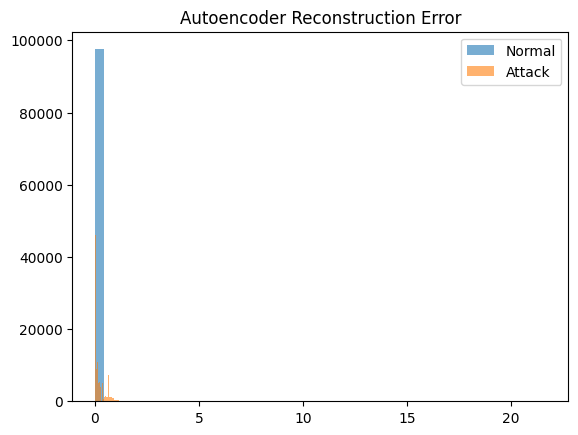

In [5]:
import matplotlib.pyplot as plt

plt.hist(reconstruction_error[y == 0], bins=50, alpha=0.6, label="Normal")
plt.hist(reconstruction_error[y == 1], bins=50, alpha=0.6, label="Attack")
plt.legend()
plt.title("Autoencoder Reconstruction Error")
plt.show()


Simple Thresholding

In [6]:
threshold = np.percentile(
    reconstruction_error[y == 0],
    95
)

ae_predictions = (reconstruction_error > threshold).astype(int)


Quick Evaluation

In [7]:
from sklearn.metrics import classification_report

print(classification_report(y, ae_predictions))


              precision    recall  f1-score   support

           0       0.68      0.95      0.79     97686
           1       0.94      0.65      0.77    128025

    accuracy                           0.78    225711
   macro avg       0.81      0.80      0.78    225711
weighted avg       0.83      0.78      0.78    225711



Save Model & Outputs

In [8]:
autoencoder.save("../models/autoencoder.keras")
print("Autoencoder saved")


Autoencoder saved


In [9]:
np.save("../data/autoencoder_errors.npy", reconstruction_error)


## Phase 4 Summary (Saved)

- Trained autoencoder on normal behavior only
- Detected anomalies using reconstruction error
- Captured behavioral deviations missed by point-anomaly models
- Saved trained neural model and anomaly scores
- Strengthened detection of insider and low-noise attacks


In [11]:
import sys
sys.path.append('../src')
from plot_utils import save_plot

plt.hist(reconstruction_error[y == 0], bins=50, alpha=0.6, label="Normal")
plt.hist(reconstruction_error[y == 1], bins=50, alpha=0.6, label="Attack")
plt.legend()
plt.title("Autoencoder Reconstruction Error")

save_plot("autoencoder_errors.png", phase="phase4")

Plot saved → ../reports/figures/phase4\autoencoder_errors.png
